Testing the image details

In [ ]:
!mkdir -p /content/data
!unzip "/content/archive (1).zip" -d "/content/data"

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/sad/Training_65242339.jpg  
  inflating: /content/data/train/sad/Training_65267116.jpg  
  inflating: /content/data/train/sad/Training_65275626.jpg  
  inflating: /content/data/train/sad/Training_6529266.jpg  
  inflating: /content/data/train/sad/Training_65329617.jpg  
  inflating: /content/data/train/sad/Training_65338712.jpg  
  inflating: /content/data/train/sad/Training_65338797.jpg  
  inflating: /content/data/train/sad/Training_65387162.jpg  
  inflating: /content/data/train/sad/Training_65404494.jpg  
  inflating: /content/data/train/sad/Training_65426218.jpg  
  inflating: /content/data/train/sad/Training_65430136.jpg  
  inflating: /content/data/train/sad/Training_65437377.jpg  
  inflating: /content/data/train/sad/Training_6545735.jpg  
  inflating: /content/data/train/sad/Training_65463385.jpg  
  inflating: /content/data/train/sad/Training_65473985.jpg  
  inflating: /content/data/train/sad

In [ ]:
import os
import random
from PIL import Image

data_dir = "/content/data/train"

def explore_images(data_dir):
  class_folder = random.choice(os.listdir(data_dir))
  class_path = os.path.join(data_dir, class_folder)

  image_file = random.choice(os.listdir(class_path))
  image_path = os.path.join(class_path, image_file)

  img = Image.open(image_path)

  print("Image details: ")
  print("File: ", image_file)
  print("size: ", img.size)
  print("Mode: ", img.mode)
  print("Format: ", img.format)

explore_images(data_dir)


Image details: 
File:  Training_30631912.jpg
size:  (48, 48)
Mode:  L
Format:  JPEG


As the images have different descriptions we need to make them similar

Importing necessary libraries

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

data_dir = "/content/data"

train_dir = "/content/data/train"
test_dir = "/content/data/test"


Converting the images from folders into datasets

In [ ]:
img_height = 48
img_width = 48
batch_size = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size = batch_size,
    color_mode = "grayscale",
    label_mode = "int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size = batch_size,
    color_mode = "grayscale",
    label_mode = "int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size = batch_size,
    color_mode = "grayscale",
    label_mode = "int",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names: ", class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Class names:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

def preprocess(image, label):
  image = normalization_layer(image)
  return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

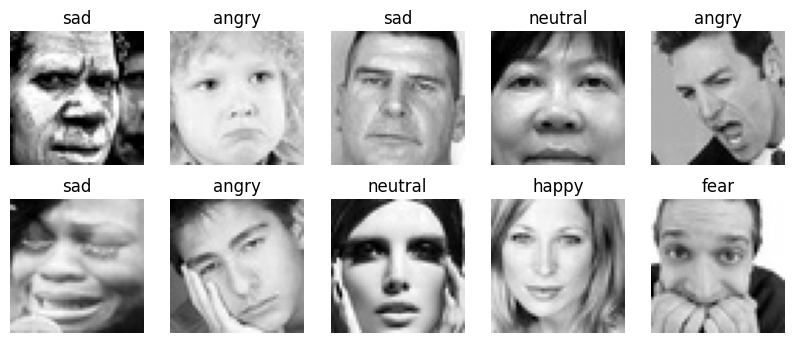

In [ ]:
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(image_batch[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[label_batch[i].numpy()])
    plt.axis("off")
plt.show()


In [ ]:
def dataset_to_numpy(ds):
  images = []
  labels = []
  for batch_images, batch_labels in ds:
    images.append(batch_images.numpy())
    labels.append(batch_labels.numpy())

  images = np.concatenate(images, axis = 0)
  labels = np.concatenate(labels, axis = 0)

  return images, labels

x_train, y_train = dataset_to_numpy(train_ds)
x_val, y_val = dataset_to_numpy(val_ds)
x_test, y_test = dataset_to_numpy(test_ds)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:  ", x_val.shape,   "y_val:  ", y_val.shape)
print("x_test: ", x_test.shape,  "y_test: ", y_test.shape)


x_train: (22968, 48, 48, 1) y_train: (22968,)
x_val:   (5741, 48, 48, 1) y_val:   (5741,)
x_test:  (7178, 48, 48, 1) y_test:  (7178,)


In [ ]:
np.savez(
    "fer2013_preprocessed.npz",
    x_train=x_train, y_train=y_train,
    x_val=x_val,     y_val=y_val,
    x_test=x_test,   y_test=y_test,
    class_names=np.array(class_names)
)

!cp fer2013_preprocessed.npz /content/drive/MyDrive/Datasets
print("Saved in drive successfully")

NameError: name 'np' is not defined